In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install fastai==2.1.5
!pip install fastcore==1.3.0

In [ ]:
!pip install timm

In [5]:
!pip list

Package                       Version        
----------------------------- ---------------
absl-py                       0.10.0         
alabaster                     0.7.12         
albumentations                0.1.12         
altair                        4.1.0          
argon2-cffi                   20.1.0         
asgiref                       3.3.1          
astor                         0.8.1          
astropy                       4.1            
astunparse                    1.6.3          
async-generator               1.10           
atari-py                      0.2.6          
atomicwrites                  1.4.0          
attrs                         20.3.0         
audioread                     2.1.9          
autograd                      1.3            
Babel                         2.9.0          
backcall                      0.2.0          
beautifulsoup4                4.6.3          
bleach                        3.2.1          
blis                          0.4.

In [6]:
import seaborn as sns
import numpy as np
import fastai
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [8]:
from fastai.vision.all import *
from fastai import *
from fastai.vision import *
from fastai.callback import *
from fastai.vision.learner import model_meta
from fastai.vision.core import *
import matplotlib.pyplot as plt
from PIL import Image
from fastai.test_utils import *

In [9]:
import torch
torch.__version__

'1.7.0+cu101'

In [10]:
torch.cuda.is_available()

True

In [11]:
import warnings
warnings.filterwarnings('ignore')
os.chdir("/content/drive/My Drive")

# EDA

In [12]:
df=pd.read_csv('train.csv')
df1=pd.read_csv('dev.csv')

In [13]:
df["is_valid"]=0
df1["is_valid"]=1

In [14]:
df2=pd.concat([df,df1], ignore_index=True)
df2.head()

,image_id,grade,pos_x,pos_y,width,height,is_valid
0,31191.jpg,A,345,95,516,530,0
1,77679.jpg,A,310,73,569,520,0
2,71334.jpg,B,215,153,507,504,0
3,17095.jpg,A,265,76,598,576,0
4,48491.jpg,A,281,148,525,554,0


In [ ]:
"""
countA=len(df2['grade'][df2['grade']=='A'])
countB=len(df2['grade'][df2['grade']=='B'])
countC=len(df2['grade'][df2['grade']=='C'])
"""

In [ ]:
"""
x=[countA,countB,countC]
plt.bar(['A','B','C'],height=x)
"""

In [ ]:
"""
img_height=[]
img_width=[]
def img_stat(csv):
    for ii in csv["width"]:
        img_width.append(ii)
    for jj in csv["height"]:
        img_height.append(jj)     
img_stat(df2)
"""

In [ ]:
#sns.distplot(img_height)

In [ ]:
#sns.distplot(img_width)

In [ ]:
"""
print(max(img_height))
print(min(img_height))
print(np.mean(img_height))
print('\n')
print(max(img_width))
print(min(img_width))
print(np.mean(img_width))
"""

# 設置資料集

In [15]:
#可能需要多讀取幾次
path = os.getcwd()+"/im_deblur/im_all"
data = ImageDataLoaders.from_df(df=df2,bs=64,path=path,item_tfms=Resize(224,ResizeMethod.Squish),batch_tfms=[*aug_transforms(), Normalize.from_stats(*imagenet_stats)])

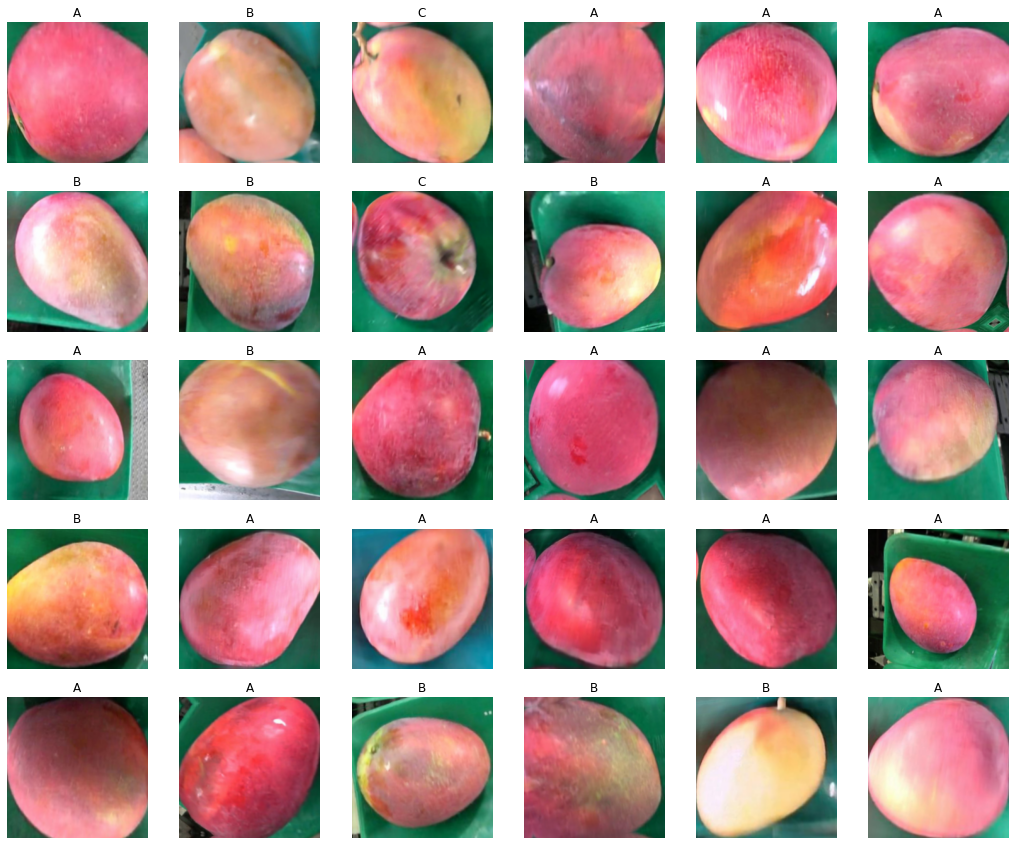

In [16]:
data.show_batch(max_n=30)

In [17]:
data.train_ds

(#41600) [(PILImage mode=RGB size=295x252, TensorCategory(2)),(PILImage mode=RGB size=492x551, TensorCategory(0)),(PILImage mode=RGB size=474x376, TensorCategory(2)),(PILImage mode=RGB size=363x306, TensorCategory(0)),(PILImage mode=RGB size=405x477, TensorCategory(2)),(PILImage mode=RGB size=279x206, TensorCategory(0)),(PILImage mode=RGB size=389x357, TensorCategory(1)),(PILImage mode=RGB size=470x408, TensorCategory(0)),(PILImage mode=RGB size=370x306, TensorCategory(0)),(PILImage mode=RGB size=356x385, TensorCategory(1))...]

In [18]:
data.valid_ds

(#10400) [(PILImage mode=RGB size=474x489, TensorCategory(0)),(PILImage mode=RGB size=401x366, TensorCategory(2)),(PILImage mode=RGB size=411x332, TensorCategory(2)),(PILImage mode=RGB size=455x400, TensorCategory(1)),(PILImage mode=RGB size=318x257, TensorCategory(1)),(PILImage mode=RGB size=468x420, TensorCategory(0)),(PILImage mode=RGB size=570x503, TensorCategory(0)),(PILImage mode=RGB size=384x263, TensorCategory(2)),(PILImage mode=RGB size=256x248, TensorCategory(0)),(PILImage mode=RGB size=551x585, TensorCategory(1))...]

# Model

In [19]:
def convert_relu_to_mish(model):
    for child_name, child in model.named_children():
        if isinstance(child, nn.ReLU):
            setattr(model, child_name, Mish())
        else:
            convert_relu_to_mish(child)

In [20]:
from timm import create_model

In [ ]:
import timm
from pprint import pprint
model_names = timm.list_models(pretrained=True)
pprint(model_names)

In [22]:
def create_timm_body(arch:str,pretrained=True,cut=None):
   model=create_model(arch,pretrained=pretrained) 
   if cut is None:
     ll = list(enumerate(model.children()))
     cut=next(i for i,o in reversed(ll) if has_pool_type(o))
   if isinstance(cut,int): return nn.Sequential(*list(model.children())[:cut])  

# Resnet

In [23]:
arch = resnet50
learn=cnn_learner(data,arch,metrics=[accuracy,Recall(average='weighted'),FBeta(1,average='weighted')],pretrained=True,path="/content/drive/My Drive/model").to_fp16()

In [24]:
convert_relu_to_mish(learn.model)
learn.opt_func = ranger

In [ ]:
learn.summary()

In [ ]:
learn.lr_find()

In [27]:
cbs = [SaveModelCallback(monitor='fbeta_score',fname='resnet50'),ShowGraphCallback()]

In [ ]:
learn.freeze()
learn.fit_flat_cos(2,1e-03,cbs=cbs)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(10,slice(1e-05,1e-03),cbs=cbs)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(7,slice(1e-05,1e-03),cbs=cbs,wd=0.01)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(6,slice(1e-05,1e-03),cbs=cbs,wd=0.1)

# Seresnext26d_32x4d

In [ ]:
ser32 = create_timm_body('seresnext26d_32x4d',pretrained=True)
ser32

In [ ]:
def create_first(body,pretrained=True,cut=None):
   return nn.Sequential(*list(body.children())[0:3])
first=create_first(ser32);first 

In [ ]:
def create_second(body,pretrained=True,cut=None):
   return nn.Sequential(*list(body.children())[3:])
second=create_second(ser32);second 

In [ ]:
head = create_head(4096,data.c);head

In [33]:
model=nn.Sequential(first,second,head);model
apply_init(model[2],nn.init.kaiming_normal_)

In [34]:
def _timm_split(m): return L(m[0], m[1], m[2]).map(params)
learn=Learner(data,model,metrics=[accuracy,Recall(average='weighted'),FBeta(1,average='weighted')],splitter=_timm_split,path="/content/drive/My Drive/model").to_fp16()

In [35]:
convert_relu_to_mish(learn.model)
learn.opt_func = ranger

In [ ]:
learn.summary()

In [ ]:
learn.lr_find()

In [38]:
cbs = [SaveModelCallback(monitor='fbeta_score',fname='ser32'),ShowGraphCallback()]

In [ ]:
learn.freeze()
learn.fit_flat_cos(2,1e-02,cbs=cbs)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(10,slice(1e-04,1e-02),cbs=cbs)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(7,slice(1e-04,1e-02),cbs=cbs,wd=0.01)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(6,slice(1e-04,1e-02),cbs=cbs,wd=0.1)

#Densenet201

In [ ]:
arch = densenet201
learn=cnn_learner(data,arch,metrics=[accuracy,Recall(average='weighted'),FBeta(1,average='weighted')],pretrained=True,path="/content/drive/My Drive/model").to_fp16()

In [41]:
convert_relu_to_mish(learn.model)
learn.opt_func = ranger

In [ ]:
learn.summary()

In [ ]:
learn.lr_find()

In [44]:
cbs = [SaveModelCallback(monitor='fbeta_score',fname='den201'),ShowGraphCallback()]

In [ ]:
learn.freeze()
learn.fit_flat_cos(2,1e-03,cbs=cbs)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(10,slice(1e-05,1e-03),cbs=cbs)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(7,slice(1e-05,1e-03),cbs=cbs,wd=0.01)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(6,slice(1e-05,1e-03),cbs=cbs,wd=0.1)

#Resnest26d

In [ ]:
res26d = create_timm_body('resnest26d',pretrained=True)
res26d

In [ ]:
def create_first(body,pretrained=True,cut=None):
   return nn.Sequential(*list(body.children())[0:3])
first=create_first(res26d);first 

In [ ]:
def create_second(body,pretrained=True,cut=None):
   return nn.Sequential(*list(body.children())[3:])
second=create_second(res26d);second

In [49]:
head = create_head(4096,data.c);head

Sequential(
  (0): AdaptiveConcatPool2d(
    (ap): AdaptiveAvgPool2d(output_size=1)
    (mp): AdaptiveMaxPool2d(output_size=1)
  )
  (1): Flatten(full=False)
  (2): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Dropout(p=0.25, inplace=False)
  (4): Linear(in_features=4096, out_features=512, bias=False)
  (5): ReLU(inplace=True)
  (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=512, out_features=3, bias=False)
)

In [50]:
model=nn.Sequential(first,second,head);model
apply_init(model[2],nn.init.kaiming_normal_)

In [71]:
def _timm_split(m): return L(m[0], m[1], m[2]).map(params)
learn=Learner(data,model,metrics=[accuracy,Recall(average='weighted'),FBeta(1,average='weighted')],splitter=_timm_split,path="/content/drive/My Drive/model").to_fp16()

In [72]:
convert_relu_to_mish(learn.model)
learn.opt_func = ranger

In [73]:
learn.summary()

Sequential (Input shape: ['64 x 3 x 224 x 224'])
Layer (type)         Output Shape         Param #    Trainable 
Conv2d               64 x 32 x 112 x 112  864        False     
________________________________________________________________
BatchNorm2d          64 x 32 x 112 x 112  64         True      
________________________________________________________________
Mish                 64 x 32 x 112 x 112  0          False     
________________________________________________________________
Conv2d               64 x 32 x 112 x 112  9,216      False     
________________________________________________________________
BatchNorm2d          64 x 32 x 112 x 112  64         True      
________________________________________________________________
Mish                 64 x 32 x 112 x 112  0          False     
________________________________________________________________
Conv2d               64 x 64 x 112 x 112  18,432     False     
_________________________________________________

In [ ]:
learn.lr_find()

In [75]:
cbs = [SaveModelCallback(monitor='fbeta_score',fname='resnest26d'),ShowGraphCallback()]

In [ ]:
learn.freeze()
learn.fit_flat_cos(2,1e-03,cbs=cbs)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(10,slice(1e-05,1e-03),cbs=cbs)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(7,slice(1e-05,1e-03),cbs=cbs,wd=0.01)

In [ ]:
learn.unfreeze()
learn.fit_flat_cos(6,slice(1e-05,1e-03),cbs=cbs,wd=0.1)

# 模型融合

In [ ]:
#majority vote

In [ ]:
test = get_image_files("/content/drive/My Drive/P2_test/Test_seg");test

In [ ]:
label=re.findall("[0-9]{5}.jpg",str(test.items));label

In [ ]:
dic = {j:i for i,j in enumerate(label)};dic

In [62]:
def average_test(dls,arch:str):
    if arch == "densenet201":
            arch = densenet201
            learn=cnn_learner(dls,arch,metrics=[accuracy,Recall(average='weighted'),FBeta(1,average='weighted')],pretrained=True,path="/content/drive/My Drive/model").to_fp16()
            learn.load("den201")  
    elif arch == "resnet50":
            arch = resnet50
            learn=cnn_learner(dls,arch,metrics=[accuracy,Recall(average='weighted'),FBeta(1,average='weighted')],pretrained=True,path="/content/drive/My Drive/model").to_fp16() 
            learn.load("resnet50")       
    elif arch == "res26d":        
            res26d = create_timm_body('resnest26d',pretrained=True)        
            def create_first(body,pretrained=True,cut=None):
                return nn.Sequential(*list(body.children())[0:3])
            first=create_first(res26d)
            def create_second(body,pretrained=True,cut=None):
                return nn.Sequential(*list(body.children())[3:])
            second=create_second(res26d)
            head = create_head(4096,dls.c);head
            model=nn.Sequential(first,second,head)
            apply_init(model[2],nn.init.kaiming_normal_)
            def _timm_split(m): return L(m[0], m[1], m[2]).map(params)
            learn=Learner(dls,model,metrics=[accuracy,Recall(average='weighted'),FBeta(1,average='weighted')],splitter=_timm_split,path="/content/drive/My Drive/model").to_fp16()           
            learn.load("resnest26d")  
    elif arch == "ser32":
            ser32 = create_timm_body('seresnext26d_32x4d',pretrained=True)
            def create_first(body,pretrained=True,cut=None):
                return nn.Sequential(*list(body.children())[0:3])
            first=create_first(ser32)
            def create_second(body,pretrained=True,cut=None):
                return nn.Sequential(*list(body.children())[3:])
            second=create_second(ser32)
            head = create_head(4096,data.c);head
            model=nn.Sequential(first,second,head)
            apply_init(model[2],nn.init.kaiming_normal_)
            def _timm_split(m): return L(m[0], m[1], m[2]).map(params)
            learn=Learner(dls,model,metrics=[accuracy,Recall(average='weighted'),FBeta(1,average='weighted')],splitter=_timm_split,path="/content/drive/My Drive/model").to_fp16()
            learn.load("ser32")  
    return learn           

In [63]:
import time
tst_preds = []

In [64]:
learn=average_test(data,"densenet201")

In [65]:
pred1,_ = learn.tta(dl=learn.dls.test_dl(test[:3000]))
time.sleep(15)
pred2,_ = learn.tta(dl=learn.dls.test_dl(test[3000:6500]))
time.sleep(15)
pred3,_ = learn.tta(dl=learn.dls.test_dl(test[6500:10000]))
time.sleep(15)
pred4,_ = learn.tta(dl=learn.dls.test_dl(test[10000:]))

In [66]:
x=torch.cat((pred1,pred2))
x=torch.cat((x,pred3))
x=torch.cat((x,pred4))
tst_preds.append(x)

In [67]:
learn=average_test(data,"resnet50")

In [68]:
pred1,_ = learn.tta(dl=learn.dls.test_dl(test[:3000]))
time.sleep(15)
pred2,_ = learn.tta(dl=learn.dls.test_dl(test[3000:6500]))
time.sleep(15)
pred3,_ = learn.tta(dl=learn.dls.test_dl(test[6500:10000]))
time.sleep(15)
pred4,_ = learn.tta(dl=learn.dls.test_dl(test[10000:]))

In [69]:
x=torch.cat((pred1,pred2))
x=torch.cat((x,pred3))
x=torch.cat((x,pred4))
tst_preds.append(x)

In [77]:
learn=average_test(data,"res26d")

In [78]:
pred1,_ = learn.tta(dl=learn.dls.test_dl(test[:3000]))
time.sleep(15)
pred2,_ = learn.tta(dl=learn.dls.test_dl(test[3000:6500]))
time.sleep(15)
pred3,_ = learn.tta(dl=learn.dls.test_dl(test[6500:10000]))
time.sleep(15)
pred4,_ = learn.tta(dl=learn.dls.test_dl(test[10000:]))

In [79]:
x=torch.cat((pred1,pred2))
x=torch.cat((x,pred3))
x=torch.cat((x,pred4))
tst_preds.append(x)

In [80]:
learn=average_test(data,"ser32")

In [81]:
pred1,_ = learn.tta(dl=learn.dls.test_dl(test[:3000]))
time.sleep(15)
pred2,_ = learn.tta(dl=learn.dls.test_dl(test[3000:6500]))
time.sleep(15)
pred3,_ = learn.tta(dl=learn.dls.test_dl(test[6500:10000]))
time.sleep(15)
pred4,_ = learn.tta(dl=learn.dls.test_dl(test[10000:]))

In [82]:
x=torch.cat((pred1,pred2))
x=torch.cat((x,pred3))
x=torch.cat((x,pred4))
tst_preds.append(x)

In [ ]:
hat = tst_preds[0]
for pred in tst_preds[1:]:
    hat += pred
hat /= len(tst_preds)
final=hat.argmax(dim=-1);final

# 預測test data、製作csv

In [ ]:
import os
os.getcwd()

In [88]:
import csv
with open('test_Final_example.csv', 'r', newline='') as csvfile:
       rows = csv.reader(csvfile)
       rows=list(rows)
rows=[ii[0] for ii in rows]      
del rows[0] 

In [ ]:
rows

In [ ]:
with open('mj_vote_mish.csv', 'w', newline='') as csvfile:
       writer = csv.writer(csvfile, delimiter=' ')
       writer.writerow(['image_id', 'label'])
       for i in rows:
            if final[dic[i]]==0:
               writer.writerow([i, 'A'])
            elif  final[dic[i]]==1:
               writer.writerow([i, 'B'])  
            elif  final[dic[i]]==2:
               writer.writerow([i, 'C'])   